In [1]:
sentence = ['The', 'cat','sat','on','the','mat']

attention_scores = {
    'The' : 0.1,
    'cat' : 1.0,
    'sat' : 0.8,
    'on' : 0.3,
    'the' : 0.1,
    'mat' : 0.6
}

In [2]:
word_vectors = {
    'The' : [0.1, 0.2, 0.3],
    'cat' : [0.5, 0.8, 0.2],
    'sat' : [0.7, 0.1, 0.9],
    'on' : [0.2, 0.6, 0.3],
    'the' : [0.1, 0.2, 0.3],
    'mat' : [0.8, 0.3, 0.5]
}

new_vector = []

for dim in range(3):
    weighted_sum = (
        0.1 * word_vectors['The'][dim] +
        1.0 * word_vectors['cat'][dim] +
        0.8 * word_vectors['sat'][dim] +
        0.3 * word_vectors['on'][dim] +
        0.1 * word_vectors['the'][dim] +
        0.6 * word_vectors['mat'][dim]
    )
    new_vector.append(weighted_sum)

print(word_vectors['cat'])
print(new_vector)

[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.37]


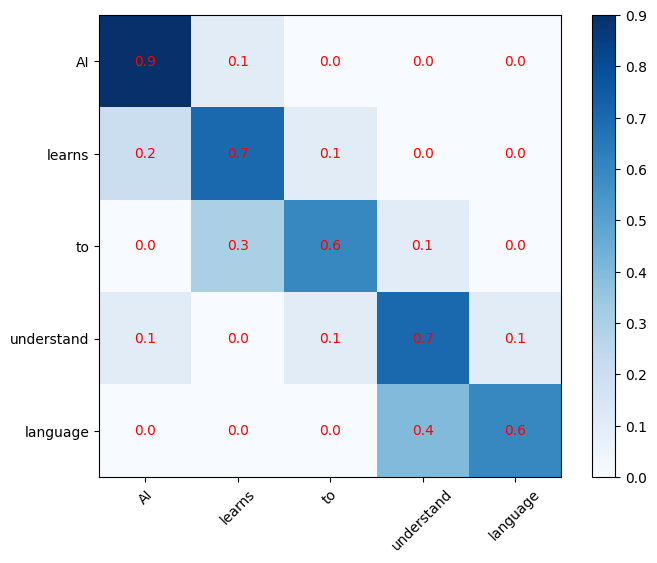

In [3]:
import matplotlib.pyplot as plt
import numpy as np

words = ['AI', 'learns', 'to', 'understand', 'language']

attention_matrix = np.array([
    [0.9, 0.1, 0.0, 0.0, 0.0],
    [0.2, 0.7, 0.1, 0.0, 0.0],
    [0.0, 0.3, 0.6, 0.1, 0.0],
    [0.1, 0.0, 0.1, 0.7, 0.1],
    [0.0, 0.0, 0.0, 0.4, 0.6]
])

plt.figure(figsize= (8,6))
plt.imshow(attention_matrix, cmap= 'Blues')
plt.xticks(range(len(words)), words, rotation = 45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f'{attention_matrix[i,j]:.1f}',
                 ha = 'center', va = 'center', color = 'red')

plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:
    def __init__(self, d_model=512):
        self.d_model = d_model

    def step_by_step_attention(self, sentence):
        print("Self-Attention 단계별 분해!")
        print("=" * 50)

        words = sentence.split()
        vocab_size = len(words)
        embeddings = torch.randn(vocab_size, self.d_model)
        for i, word in enumerate(words):
            print(words, embeddings[i][:5].tolist())

        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @ W_q
        K = embeddings @ W_k
        V = embeddings @ W_v

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)
        print(scores.shape)

        attention_weights = F.softmax(scores, dim=-1)

        plt.figure(figsize=(10, 8))
        plt.imshow(attention_weights.detach().numpy(), cmap='Blues')
        plt.xticks(range(len(words)), words, rotation=45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f'{attention_weights[i,j]:.2f}',
                        ha='center', va='center',
                        color='red' if attention_weights[i,j] > 0.3 else 'black')

        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()
        return output, attention_weights

In [5]:
def run_attention_demo():
    explainer = SelfAttentionExplainer()

    sentences = [
        "The cat sat on the mat",
        "AI learns to understand language",
        "Transformer models revolutionized NLP"
    ]

    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)

In [6]:
class PracticalAttentionExample:
    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=512,
            num_heads=8,
            batch_first=True
        )

    def text_classification_with_attention(self):
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)

        attn_output, attn_weights = self.multihead_attn(
            text_embeddings, text_embeddings, text_embeddings
        )

        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)

        classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 3)
        )

        pooled = attn_output.mean(dim=1)
        predictions = classifier(pooled)

        print(predictions.shape)
        return predictions

Self-Attention 단계별 분해!
['The', 'cat', 'sat', 'on', 'the', 'mat'] [0.5098870992660522, 0.029721805825829506, -0.9232915639877319, 0.4704716205596924, -0.49325117468833923]
['The', 'cat', 'sat', 'on', 'the', 'mat'] [-1.053498387336731, 0.048654403537511826, -0.4325856864452362, -1.1342333555221558, -0.8008948564529419]
['The', 'cat', 'sat', 'on', 'the', 'mat'] [0.17997340857982635, -1.4040992259979248, -0.34867388010025024, 1.0546516180038452, -0.09237802773714066]
['The', 'cat', 'sat', 'on', 'the', 'mat'] [0.2564507722854614, -0.8219233155250549, 0.9447566866874695, 0.1395729035139084, -0.33272647857666016]
['The', 'cat', 'sat', 'on', 'the', 'mat'] [-0.4029986560344696, -1.8034361600875854, -0.15376900136470795, -0.6902335286140442, 2.69381046295166]
['The', 'cat', 'sat', 'on', 'the', 'mat'] [0.15239973366260529, -0.11939975619316101, 0.942013680934906, -0.5744370222091675, 0.36021578311920166]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 6])


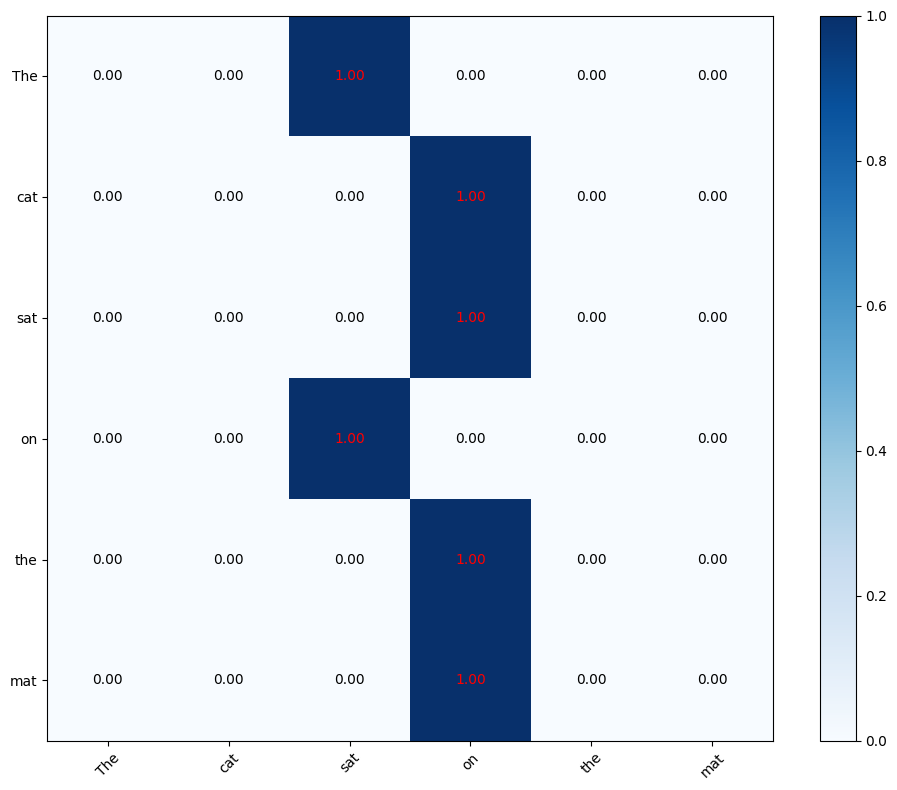

torch.Size([6, 512])
Self-Attention 단계별 분해!
['AI', 'learns', 'to', 'understand', 'language'] [-0.5106951594352722, 0.04758017882704735, 0.4637644588947296, -0.6450693607330322, -0.7170124650001526]
['AI', 'learns', 'to', 'understand', 'language'] [-0.46839413046836853, 1.2780791521072388, 0.48101383447647095, -1.049660325050354, 1.0883170366287231]
['AI', 'learns', 'to', 'understand', 'language'] [0.6014260053634644, 0.6629932522773743, 0.0023002824746072292, 1.7201834917068481, -0.37815558910369873]
['AI', 'learns', 'to', 'understand', 'language'] [0.6067540049552917, -1.356797456741333, -0.15010344982147217, -1.138854742050171, 1.5833534002304077]
['AI', 'learns', 'to', 'understand', 'language'] [0.7292472124099731, 1.0251133441925049, 0.6077576875686646, -0.49069449305534363, 1.2746505737304688]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 5])


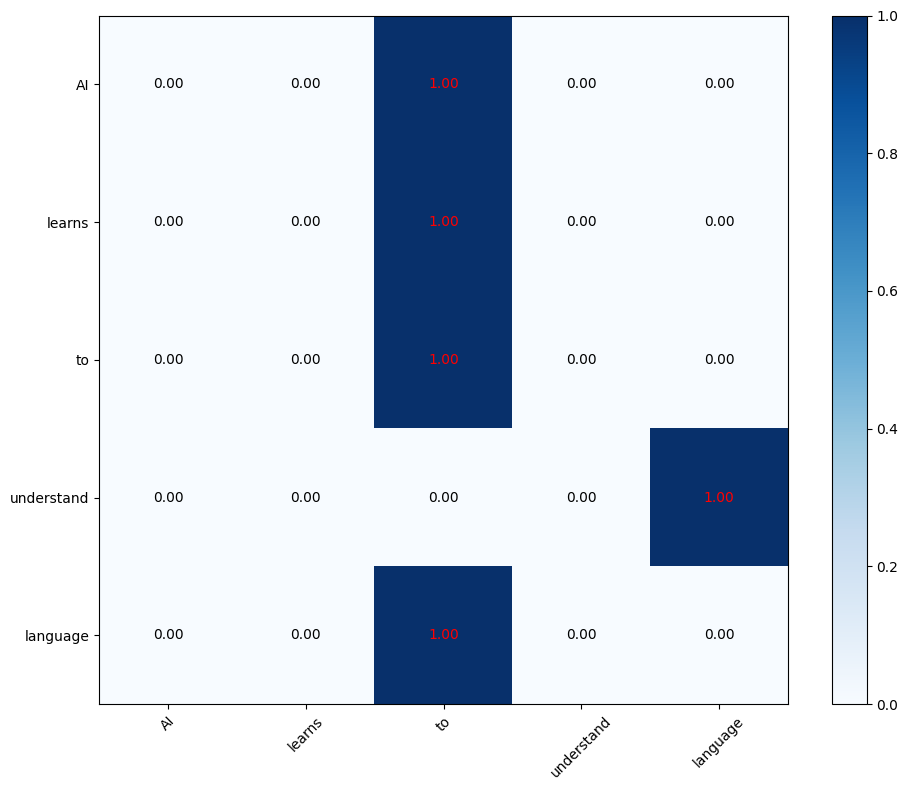

torch.Size([5, 512])
Self-Attention 단계별 분해!
['Transformer', 'models', 'revolutionized', 'NLP'] [-0.26611432433128357, 1.4555151462554932, -0.5405097603797913, 1.3923118114471436, -0.9559275507926941]
['Transformer', 'models', 'revolutionized', 'NLP'] [-1.2490334510803223, -1.8342540264129639, 1.3214952945709229, -0.3851938545703888, 0.5062498450279236]
['Transformer', 'models', 'revolutionized', 'NLP'] [-2.226003408432007, -0.22924210131168365, -1.0155813694000244, -0.7845377326011658, 0.462063729763031]
['Transformer', 'models', 'revolutionized', 'NLP'] [1.516701579093933, -0.025207767263054848, 0.06781072169542313, 1.532424807548523, -0.5079261064529419]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 4])


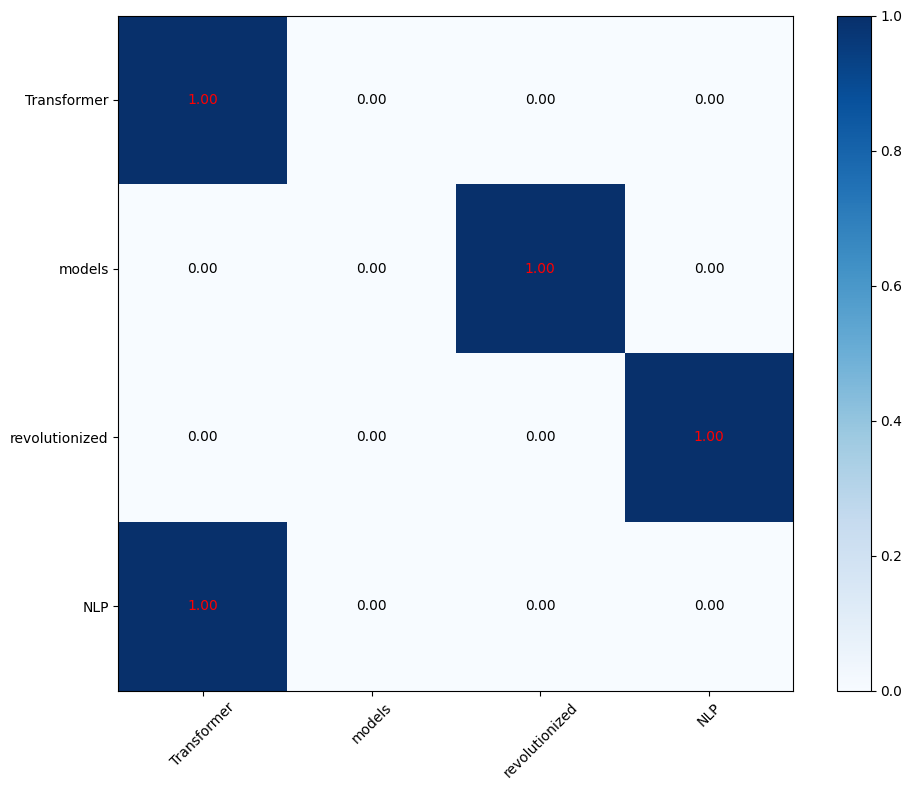

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[-0.0543, -0.0167, -0.0338],
        [-0.0260,  0.0379,  0.0085]], grad_fn=<AddmmBackward0>)

In [7]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()

적용된 폰트: ['Malgun Gothic']


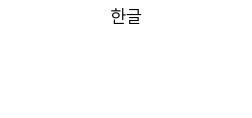

In [8]:
import platform
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [9]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

sentence = "This movie was fantastic!"
inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)

outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim=1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1


In [10]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained=True)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)
resnet18.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

img = Image.open("example.jpg").convert("RGB")
img_t = transform(img)
img_t = img_t.unsqueeze(0)
outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KDS23\Documents\17-deep-learning\.venv\lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


4


In [11]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sentences = ["I love this movie", "I hate this movie", "It was okay", "Fantastic film", "Terrible experience"]
labels = torch.tensor([1, 0, 1, 1, 0])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
dataset = TensorDataset(encoded_inputs['input_ids'], labels)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

model_fe = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
for param in model_fe.bert.parameters():
    param.requires_grad = False
optimizer_fe = optim.Adam(model_fe.parameters(), lr=2e-5)

model_ft = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=2e-5)

def train_model(model, optimizer, epochs=3):
    model.train()
    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, labels=label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
